## RealMLP on Predicting Heart Disease

**Score**
- PB:
- CV: 0.954583

**Note**
- Add Numeric Encoding Variants for RealMLP and Compare CV AUCs
- Notebook feature pipeline will accept new encoding configurations.
- Training cell will no longer coerce all columns to categorical; it will rely on the feature builder’s cat_cols and num_cols to keep mixed dtypes.


### Package import

In [8]:
!pip install pytabkit -q

from pathlib import Path
import json
import zipfile
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import warnings
from sklearn.metrics import roc_auc_score
from pytabkit import RealMLP_TD_Classifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

# ---- Config ----
COMP_SLUG = "playground-series-s6e2"
KAGGLE_COMP_DIR = Path("/kaggle/input/competitions/playground-series-s6e2")
KAGGLE_EXT_PATH = Path("/kaggle/input/datasets/neurocipher/heartdisease/Heart_Disease_Prediction.csv")

LOCAL_DATA_DIR = Path("data/raw")
LOCAL_DATA_DIR.mkdir(parents=True, exist_ok=True)

NEED_FILES = ["train.csv", "test.csv", "sample_submission.csv"]

In [9]:
def run(cmd: list[str]) -> None:
    p = subprocess.run(cmd, capture_output=True, text=True)
    p.check_returncode()


def ensure_kaggle_cli() -> None:
    try:
        pass
    except Exception:
        subprocess.check_call(["pip", "-q", "install", "kaggle"])


def ensure_kaggle_json_interactive_colab(dst: Path = Path("/content/kaggle.json")) -> Path:
    """
    In Colab: open upload dialog if /content/kaggle.json is missing.
    In non-Colab: just require the file to exist.
    """
    if dst.exists():
        print("Found:", dst)
        return dst

    try:
        from google.colab import files  # type: ignore
    except Exception:
        raise FileNotFoundError(
            f"{dst} not found. Please place kaggle.json at {dst} (Colab) "
            "or provide credentials another way."
        )

    print("Upload your kaggle.json (Kaggle -> Account -> API -> Create New Token)")
    uploaded = files.upload()
    cand = None
    if "kaggle.json" in uploaded:
        cand = "kaggle.json"
    else:
        for name in uploaded.keys():
            if name.endswith(".json"):
                cand = name
                break
    if cand is None:
        raise FileNotFoundError("Upload failed: no .json file received.")

    Path(cand).rename(dst)
    print("Saved to:", dst)
    return dst


def install_kaggle_json(src: Path) -> None:
    """
    Copy /content/kaggle.json -> ~/.kaggle/kaggle.json (chmod 600)
    """
    if not src.exists():
        raise FileNotFoundError(f"{src} not found.")

    dst_dir = Path.home() / ".kaggle"
    dst_dir.mkdir(parents=True, exist_ok=True)
    dst = dst_dir / "kaggle.json"

    dst.write_bytes(src.read_bytes())
    try:
        dst.chmod(0o600)
    except Exception:
        pass

    cfg = json.loads(dst.read_text())
    if "username" not in cfg or "key" not in cfg:
        raise ValueError("kaggle.json is missing 'username' or 'key'.")
    print(f"Installed kaggle.json for user: {cfg['username']}")


def local_data_ready(data_dir: Path) -> bool:
    return all((data_dir / f).exists() for f in NEED_FILES)


def download_competition_to(data_dir: Path) -> None:
    """
    Download competition zip(s) and extract into data_dir.
    Assumes kaggle CLI + credentials are ready.
    """
    run(["kaggle", "config", "view"])
    run(["kaggle", "competitions", "download", "-c", COMP_SLUG, "-p", str(data_dir), "--force"])

    zips = list(data_dir.glob("*.zip"))
    if not zips:
        raise FileNotFoundError(f"No zip found in {data_dir} after download.")

    for zp in zips:
        with zipfile.ZipFile(zp, "r") as zf:
            zf.extractall(data_dir)
        print("Unzipped:", zp.name)

    if not local_data_ready(data_dir):
        missing = [f for f in NEED_FILES if not (data_dir / f).exists()]
        raise FileNotFoundError(f"Download/unzip finished but missing: {missing}")


In [10]:
if KAGGLE_COMP_DIR.exists():
    DATA_SRC = "kaggle"
    data_dir = KAGGLE_COMP_DIR
    print("Using Kaggle mounted competition data:", data_dir)
else:
    DATA_SRC = "local"
    data_dir = LOCAL_DATA_DIR
    if local_data_ready(data_dir):
        print("Using local data (already present):", data_dir)
    else:
        print("Local data missing -> download using kaggle.json")
        ensure_kaggle_cli()
        kaggle_json_src = ensure_kaggle_json_interactive_colab(Path("/content/kaggle.json"))
        install_kaggle_json(kaggle_json_src)
        download_competition_to(data_dir)
        print("Download complete -> using local data:", data_dir)


# ---- Load ----
train = pd.read_csv(data_dir / "train.csv")
test  = pd.read_csv(data_dir / "test.csv")
sub   = pd.read_csv(data_dir / "sample_submission.csv")

# external dataset: only available if mounted on Kaggle; optional
original = pd.read_csv(KAGGLE_EXT_PATH) if KAGGLE_EXT_PATH.exists() else None

print("train:", train.shape, "test:", test.shape, "sub:", sub.shape, "original:", None if original is None else original.shape)
print("DATA_SRC:", DATA_SRC)

# External data loading
train_comp = train.copy()

# Encode target with LabelEncoder if not numeric
if not pd.api.types.is_numeric_dtype(train_comp["Heart Disease"]):
    le = LabelEncoder()
    train_comp["Heart Disease"] = le.fit_transform(train_comp["Heart Disease"])
    if original is not None and "Heart Disease" in original.columns:
        original["Heart Disease"] = le.transform(original["Heart Disease"])

# Align external columns to train schema
if original is not None:
    if "Heart Disease" not in original.columns:
        raise ValueError("External dataset missing target column: Heart Disease")

    original_aligned = original.copy()
    # add missing columns
    for col in train_comp.columns:
        if col not in original_aligned.columns:
            original_aligned[col] = np.nan

    # ensure id exists
    if "id" not in original_aligned.columns:
        original_aligned["id"] = -(np.arange(len(original_aligned)) + 1)

    # align column order
    original_aligned = original_aligned[train_comp.columns]

    train_full = pd.concat([train_comp, original_aligned], ignore_index=True)
    train_full["is_external"] = [0] * len(train_comp) + [1] * len(original_aligned)
else:
    train_full = train_comp.copy()
    train_full["is_external"] = 0

# use concatenated data for downstream
train = train_full


Using local data (already present): data/raw
train: (630000, 15) test: (270000, 14) sub: (270000, 2) original: None
DATA_SRC: local


In [11]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(RANDOM_STATE)
    torch.set_float32_matmul_precision("high")
N_FOLDS = 5
USE_ALL_CAT = True

print(f"Using device: {DEVICE}")


Using device: cuda


### Data download

In [12]:
display(train.head())
display(test.head())
display(sub.head())

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease,is_external
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1,0
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0,0
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0,0
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0,0
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,1,0


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,630000,58,1,3,120,288,0,2,145,1,0.8,2,3,3
1,630001,55,0,2,120,209,0,0,172,0,0.0,1,0,3
2,630002,54,1,4,120,268,0,0,150,1,0.0,2,3,7
3,630003,44,0,3,112,177,0,0,168,0,0.9,1,0,3
4,630004,43,1,1,138,267,0,0,163,0,1.8,2,0,7


,id,Heart Disease
0,630000,0
1,630001,0
2,630002,0
3,630003,0
4,630004,0


In [13]:
# Shapes
print("train:", train.shape)
print("test:", test.shape)

# Column diffs
train_cols = set(train.columns)
test_cols = set(test.columns)
print("Only in train:", sorted(train_cols - test_cols))
print("Only in test:", sorted(test_cols - train_cols))

# dtypes
train.dtypes.to_frame("dtype").head(30)


train: (630000, 16)
test: (270000, 14)
Only in train: ['Heart Disease', 'is_external']
Only in test: []


,dtype
id,int64
Age,int64
Sex,int64
Chest pain type,int64
BP,int64
Cholesterol,int64
FBS over 120,int64
EKG results,int64
Max HR,int64
Exercise angina,int64


### Data Preprocessing

In [14]:
def encode_target_strict(y: pd.Series) -> pd.Series:
    """Map common string labels to {0,1}. Raises if unknown."""
    mapping_candidates = [
        {"No": 0, "Yes": 1},
        {"N": 0, "Y": 1},
        {"Negative": 0, "Positive": 1},
        {"Absent": 0, "Present": 1},
        {"Absence": 0, "Presence": 1},
        {0: 0, 1: 1},
        {"0": 0, "1": 1},
    ]
    uniq = set(pd.Series(y).dropna().unique().tolist())
    for mp in mapping_candidates:
        if uniq.issubset(set(mp.keys())):
            return pd.Series(y).map(mp).astype("int8")
    raise ValueError(f"Unknown target labels: {sorted(list(uniq))}")


# ---- target ----
if not pd.api.types.is_numeric_dtype(train["Heart Disease"]):
    train["Heart Disease"] = encode_target_strict(train["Heart Disease"])
if original is not None and "Heart Disease" in original.columns:
    if not pd.api.types.is_numeric_dtype(original["Heart Disease"]):
        original["Heart Disease"] = encode_target_strict(original["Heart Disease"])

TARGET_COL = "Heart Disease"
ID_COL = "id"
META_COLS = [TARGET_COL, ID_COL, "is_external"]

BASE_FEATURES = [c for c in train.columns if c not in META_COLS]

# Canonical S6E2 semantic categoricals (keep as category for embeddings/encoding)
CANONICAL_CAT = {
    "Sex",
    "Chest pain type",
    "FBS over 120",
    "EKG results",
    "Exercise angina",
    "Slope of ST",
    "Number of vessels fluro",
    "Thallium",
}

def split_cols(df: pd.DataFrame):
    base = [c for c in df.columns if c not in META_COLS]
    cat = [c for c in base if c in CANONICAL_CAT]
    num = [c for c in base if c not in cat]
    return cat, num


def add_external_target_stats(df: pd.DataFrame, original_df: pd.DataFrame | None) -> pd.DataFrame:
    """Merge group-wise target stats from the external/original dataset.
    Safe in Playground comps because original_df labels are not the competition labels.
    """
    if original_df is None:
        return df.copy()

    out = df.copy()
    initial_rows = len(out)

    for col in BASE_FEATURES:
        if col not in original_df.columns:
            continue

        stats = (
            original_df.groupby(col)[TARGET_COL]
            .agg(["mean", "median", "std", "skew", "count"])
            .reset_index()
        )
        stats.columns = [col] + [f"orig_{col}_{s}" for s in ["mean", "median", "std", "skew", "count"]]

        out = out.merge(stats, on=col, how="left")
        if len(out) != initial_rows:
            raise ValueError(f"Merge expanded rows for column {col}! {initial_rows} -> {len(out)}")

        # fill NAs for unseen values
        global_mean = float(original_df[TARGET_COL].mean())
        global_median = float(original_df[TARGET_COL].median())
        fill = {
            f"orig_{col}_mean": global_mean,
            f"orig_{col}_median": global_median,
            f"orig_{col}_std": 0.0,
            f"orig_{col}_skew": 0.0,
            f"orig_{col}_count": 0.0,
        }
        out = out.fillna(value=fill)

    return out


def add_frequency_encoding(train_df: pd.DataFrame, test_df: pd.DataFrame, cols: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Add {col}_freq columns using combined train+test frequencies (unsupervised, safe)."""
    tr = train_df.copy()
    te = test_df.copy()

    combined = pd.concat([tr[cols], te[cols]], axis=0, ignore_index=True)
    for col in cols:
        freq = combined[col].value_counts(dropna=False)
        tr[f"{col}_freq"] = tr[col].map(freq).astype("float32")
        te[f"{col}_freq"] = te[col].map(freq).astype("float32")
    return tr, te


def add_binned_numerics(train_df: pd.DataFrame, test_df: pd.DataFrame, num_cols: list[str], n_bins: int = 10):
    tr = train_df.copy()
    te = test_df.copy()

    for col in num_cols:
        allv = pd.concat([tr[col], te[col]], axis=0, ignore_index=True)

        # If low cardinality, just reuse as "bin" (stable int codes)
        if allv.nunique(dropna=False) <= n_bins:
            tr[f"{col}_bin"] = pd.Series(tr[col]).astype("int32", errors="ignore")
            te[f"{col}_bin"] = pd.Series(te[col]).astype("int32", errors="ignore")
            continue

        try:
            bins = pd.qcut(allv.rank(method="first"), q=n_bins, labels=False, duplicates="drop")
        except Exception:
            bins = pd.cut(allv, bins=n_bins, labels=False, duplicates="drop")

        tr[f"{col}_bin"] = bins.iloc[:len(tr)].astype("int16")
        te[f"{col}_bin"] = bins.iloc[len(tr):].astype("int16")

    return tr, te


def compute_periodic_t_map(train_df: pd.DataFrame, cols: list[str]) -> dict[str, float]:
    t_map: dict[str, float] = {}
    for col in cols:
        series = pd.to_numeric(train_df[col], errors="coerce")
        t = float(series.max() - series.min())
        if not np.isfinite(t) or t <= 0:
            t = 1.0
        t_map[col] = t
    return t_map


def add_periodic_encoding(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    cols: list[str],
    t_map: dict[str, float],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    tr = train_df.copy()
    te = test_df.copy()

    for col in cols:
        t = t_map.get(col, 1.0)
        tr_col = pd.to_numeric(tr[col], errors="coerce").astype("float32")
        te_col = pd.to_numeric(te[col], errors="coerce").astype("float32")
        tr[f"{col}_sin"] = np.sin(2 * np.pi * tr_col / t).astype("float32")
        tr[f"{col}_cos"] = np.cos(2 * np.pi * tr_col / t).astype("float32")
        te[f"{col}_sin"] = np.sin(2 * np.pi * te_col / t).astype("float32")
        te[f"{col}_cos"] = np.cos(2 * np.pi * te_col / t).astype("float32")

    return tr, te


def add_ple_encoding(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    cols: list[str],
    n_bins: int = 10,
    keep_raw_numeric: bool = False,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    tr = train_df.copy()
    te = test_df.copy()

    for col in cols:
        tr_col = pd.to_numeric(tr[col], errors="coerce")
        te_col = pd.to_numeric(te[col], errors="coerce")

        try:
            bins = pd.qcut(tr_col.rank(method="first"), q=n_bins, retbins=True, duplicates="drop")
            bin_edges = bins[1]
        except Exception:
            bin_edges = pd.cut(tr_col, bins=n_bins, retbins=True, duplicates="drop")[1]

        tr_bin = pd.cut(tr_col, bins=bin_edges, labels=False, include_lowest=True)
        te_bin = pd.cut(te_col, bins=bin_edges, labels=False, include_lowest=True)

        n_final_bins = int(np.nanmax(tr_bin)) + 1 if tr_bin.notna().any() else 0
        for b in range(n_final_bins):
            tr[f"{col}_ple_{b}"] = (tr_bin == b).astype("float32")
            te[f"{col}_ple_{b}"] = (te_bin == b).astype("float32")

        if not keep_raw_numeric:
            tr = tr.drop(columns=[col])
            te = te.drop(columns=[col])

    return tr, te


def build_features(
    train_fe: pd.DataFrame,
    test_fe: pd.DataFrame,
    cat_cols: list[str],
    num_cols: list[str],
    encoding_cfg: dict,
):
    tr = train_fe.copy()
    te = test_fe.copy()

    base_numeric = [c for c in num_cols if not c.startswith("orig_")]

    if encoding_cfg.get("use_periodic", False):
        t_map = compute_periodic_t_map(tr, base_numeric)
        tr, te = add_periodic_encoding(tr, te, base_numeric, t_map)

    if encoding_cfg.get("use_ple", False):
        tr, te = add_ple_encoding(
            tr, te, base_numeric,
            n_bins=encoding_cfg.get("ple_bins", 10),
            keep_raw_numeric=encoding_cfg.get("keep_raw_numeric", False),
        )

    if encoding_cfg.get("use_bins", False):
        tr, te = add_binned_numerics(tr, te, base_numeric, n_bins=encoding_cfg.get("bin_count", 10))

    print(f"Train Shape after FE: {tr.shape}")
    print(f"Test Shape after FE:  {te.shape}")

    # ---- Build X/y with clean dtypes ----
    drop_tr = [c for c in META_COLS if c in tr.columns]
    drop_te = [c for c in [ID_COL] if c in te.columns]

    X = tr.drop(columns=drop_tr).copy()
    X_test = te.drop(columns=drop_te).copy()
    y = tr[TARGET_COL].copy()

    bin_cols = [c for c in X.columns if c.endswith("_bin")]

    cat_cols_final = [c for c in X.columns if c in cat_cols] + bin_cols
    num_cols_final = [c for c in X.columns if c not in cat_cols_final]

    # Ensure no overlap
    assert set(cat_cols_final).isdisjoint(set(num_cols_final))

    for c in cat_cols_final:
        combined = pd.concat([X[c], X_test[c]], axis=0, ignore_index=True)
        cats = pd.Categorical(combined).categories
        X[c] = pd.Categorical(X[c], categories=cats)
        X_test[c] = pd.Categorical(X_test[c], categories=cats)

    for c in num_cols_final:
        X[c] = pd.to_numeric(X[c], errors="coerce").astype("float32")
        X_test[c] = pd.to_numeric(X_test[c], errors="coerce").astype("float32")

    return X, X_test, y, cat_cols_final, num_cols_final


# ---- Feature engineering (per EDA) ----
train_fe = add_external_target_stats(train, original)
test_fe  = add_external_target_stats(test, original)

cat_cols, num_cols = split_cols(train_fe)
BASE_NUMERIC_COLS = [c for c in num_cols if not c.startswith("orig_")]

# Frequency encoding for semantic categoricals
train_fe, test_fe = add_frequency_encoding(train_fe, test_fe, cat_cols)

CONFIGS = {
    "raw_numeric": {
        "use_bins": False,
        "use_periodic": False,
        "use_ple": False,
        "keep_raw_numeric": True,
    },
    "periodic_only": {
        "use_bins": False,
        "use_periodic": True,
        "use_ple": False,
        "keep_raw_numeric": False,
    },
    "ple_only": {
        "use_bins": False,
        "use_periodic": False,
        "use_ple": True,
        "keep_raw_numeric": False,
    },
    "numeric_plus_bins": {
        "use_bins": True,
        "use_periodic": False,
        "use_ple": False,
        "keep_raw_numeric": True,
    },
}

features = {}
for name, cfg in CONFIGS.items():
    print(f"=== Building features: {name} ===")
    X_tmp, X_test_tmp, y_tmp, cat_cols_final, num_cols_final = build_features(
        train_fe, test_fe, cat_cols, num_cols, cfg
    )

    if cfg.get("use_bins"):
        assert any(c.endswith("_bin") for c in X_tmp.columns)
    else:
        assert not any(c.endswith("_bin") for c in X_tmp.columns)

    if cfg.get("use_periodic"):
        assert any(c.endswith("_sin") for c in X_tmp.columns)
        assert any(c.endswith("_cos") for c in X_tmp.columns)

    if cfg.get("use_ple"):
        assert any("_ple_" in c for c in X_tmp.columns)

    assert all(str(X_tmp[c].dtype) == "category" for c in cat_cols_final)
    assert all(X_tmp[c].dtype == "float32" for c in num_cols_final)

    print("Categorical cols:", len(cat_cols_final))
    print("Numeric cols:", len(num_cols_final))

    features[name] = {
        "X": X_tmp,
        "X_test": X_test_tmp,
        "y": y_tmp,
        "cat_cols": cat_cols_final,
        "num_cols": num_cols_final,
    }

# Default config for downstream cells (will be updated after evaluation)
PRIMARY_CONFIG = "raw_numeric"
X = features[PRIMARY_CONFIG]["X"]
X_test = features[PRIMARY_CONFIG]["X_test"]
y = features[PRIMARY_CONFIG]["y"]
cat_cols = features[PRIMARY_CONFIG]["cat_cols"]

print(f"PRIMARY_CONFIG={PRIMARY_CONFIG}")
print(f"X: {X.shape}, X_test: {X_test.shape}, y: {y.shape}")


=== Building features: raw_numeric ===
Train Shape after FE: (630000, 24)
Test Shape after FE:  (270000, 22)
Categorical cols: 8
Numeric cols: 13
=== Building features: periodic_only ===
Train Shape after FE: (630000, 34)
Test Shape after FE:  (270000, 32)
Categorical cols: 8
Numeric cols: 23
=== Building features: ple_only ===
Train Shape after FE: (630000, 24)
Test Shape after FE:  (270000, 22)
Categorical cols: 8
Numeric cols: 13
=== Building features: numeric_plus_bins ===
Train Shape after FE: (630000, 29)
Test Shape after FE:  (270000, 27)
Categorical cols: 13
Numeric cols: 13
PRIMARY_CONFIG=raw_numeric
X: (630000, 21), X_test: (270000, 21), y: (630000,)


### Data Quality Check

In [15]:
def check_data_quality(df, name="Dataset"):
    print(f"--- Data Quality: {name} ---")
    print(f"Total Rows: {len(df)}")

    cols_to_check = [c for c in df.columns if c != 'id']
    dupes = df.duplicated(subset=cols_to_check).sum()

    nan_counts = df.isnull().sum()
    total_nans = nan_counts.sum()

    print(f"Duplicate Rows (excl. ID): {dupes}")
    print(f"Total NaN values: {total_nans}")
    if total_nans > 0:
        print("\nColumns with NaNs:")
        print(nan_counts[nan_counts > 0])
    print("-" * 30)

check_data_quality(train, "Train")
check_data_quality(test, "Test")

--- Data Quality: Train ---
Total Rows: 630000
Duplicate Rows (excl. ID): 0
Total NaN values: 0
------------------------------
--- Data Quality: Test ---
Total Rows: 270000
Duplicate Rows (excl. ID): 0
Total NaN values: 0
------------------------------


### Feature Uniqueness & Cardinality

In [16]:
# Target distribution analysis

def analyze_uniqueness(df):
    unique_stats = []
    for col in df.columns:
        if col == 'id':
            continue

        n_unique = df[col].nunique()
        dtype = df[col].dtype

        category_guess = "Categorical/Ordinal" if n_unique < 25 else "Continuous"

        if pd.api.types.is_numeric_dtype(df[col]):
            mean_val = float(pd.to_numeric(df[col], errors='coerce').mean())
            std_val = float(pd.to_numeric(df[col], errors='coerce').std())
        else:
            mean_val = float('nan')
            std_val = float('nan')

        unique_stats.append({
            'Feature': col,
            'Unique Values': n_unique,
            'Data Type': dtype,
            'Heuristic Type': category_guess,
            'Mean': mean_val,
            'Std': std_val,
        })

    return pd.DataFrame(unique_stats).sort_values(by='Unique Values')

# class imbalance
comp_mask = (train["is_external"] == 0)
ext_mask  = (train["is_external"] == 1)

print("=== Target distribution: COMP ONLY ===")
print(train.loc[comp_mask, TARGET_COL].value_counts(dropna=False))
print(train.loc[comp_mask, TARGET_COL].value_counts(normalize=True, dropna=False))

print("\n=== Target distribution: EXTERNAL ONLY ===")
print(train.loc[ext_mask, TARGET_COL].value_counts(dropna=False))
print(train.loc[ext_mask, TARGET_COL].value_counts(normalize=True, dropna=False))

print("\n=== Target distribution: MERGED (comp + external) ===")
print(train[TARGET_COL].value_counts(dropna=False))
print(train[TARGET_COL].value_counts(normalize=True, dropna=False))

uniqueness_df = analyze_uniqueness(train)
uniqueness_df


=== Target distribution: COMP ONLY ===
Heart Disease
0    347546
1    282454
Name: count, dtype: int64
Heart Disease
0    0.55166
1    0.44834
Name: proportion, dtype: float64

=== Target distribution: EXTERNAL ONLY ===
Series([], Name: count, dtype: int64)
Series([], Name: proportion, dtype: float64)

=== Target distribution: MERGED (comp + external) ===
Heart Disease
0    347546
1    282454
Name: count, dtype: int64
Heart Disease
0    0.55166
1    0.44834
Name: proportion, dtype: float64


,Feature,Unique Values,Data Type,Heuristic Type,Mean,Std
14,is_external,1,int64,Categorical/Ordinal,0.000000,0.000000
1,Sex,2,int64,Categorical/Ordinal,0.714735,0.451541
8,Exercise angina,2,int64,Categorical/Ordinal,0.273725,0.445870
5,FBS over 120,2,int64,Categorical/Ordinal,0.079987,0.271274
13,Heart Disease,2,int64,Categorical/Ordinal,0.448340,0.497324
10,Slope of ST,3,int64,Categorical/Ordinal,1.455871,0.545192
6,EKG results,3,int64,Categorical/Ordinal,0.981660,0.998783
12,Thallium,3,int64,Categorical/Ordinal,4.618873,1.950007
2,Chest pain type,4,int64,Categorical/Ordinal,3.312752,0.851615
11,Number of vessels fluro,4,int64,Categorical/Ordinal,0.451040,0.798549


### Visualize Top Skewed Features

Top 6 Most Skewed Features (Absolute Values):
EKG results_freq       -16.972622
FBS over 120_freq       -3.096606
Slope of ST_freq        -1.947209
Thallium_freq           -1.354339
ST depression            1.328429
Exercise angina_freq    -1.014983
dtype: float32


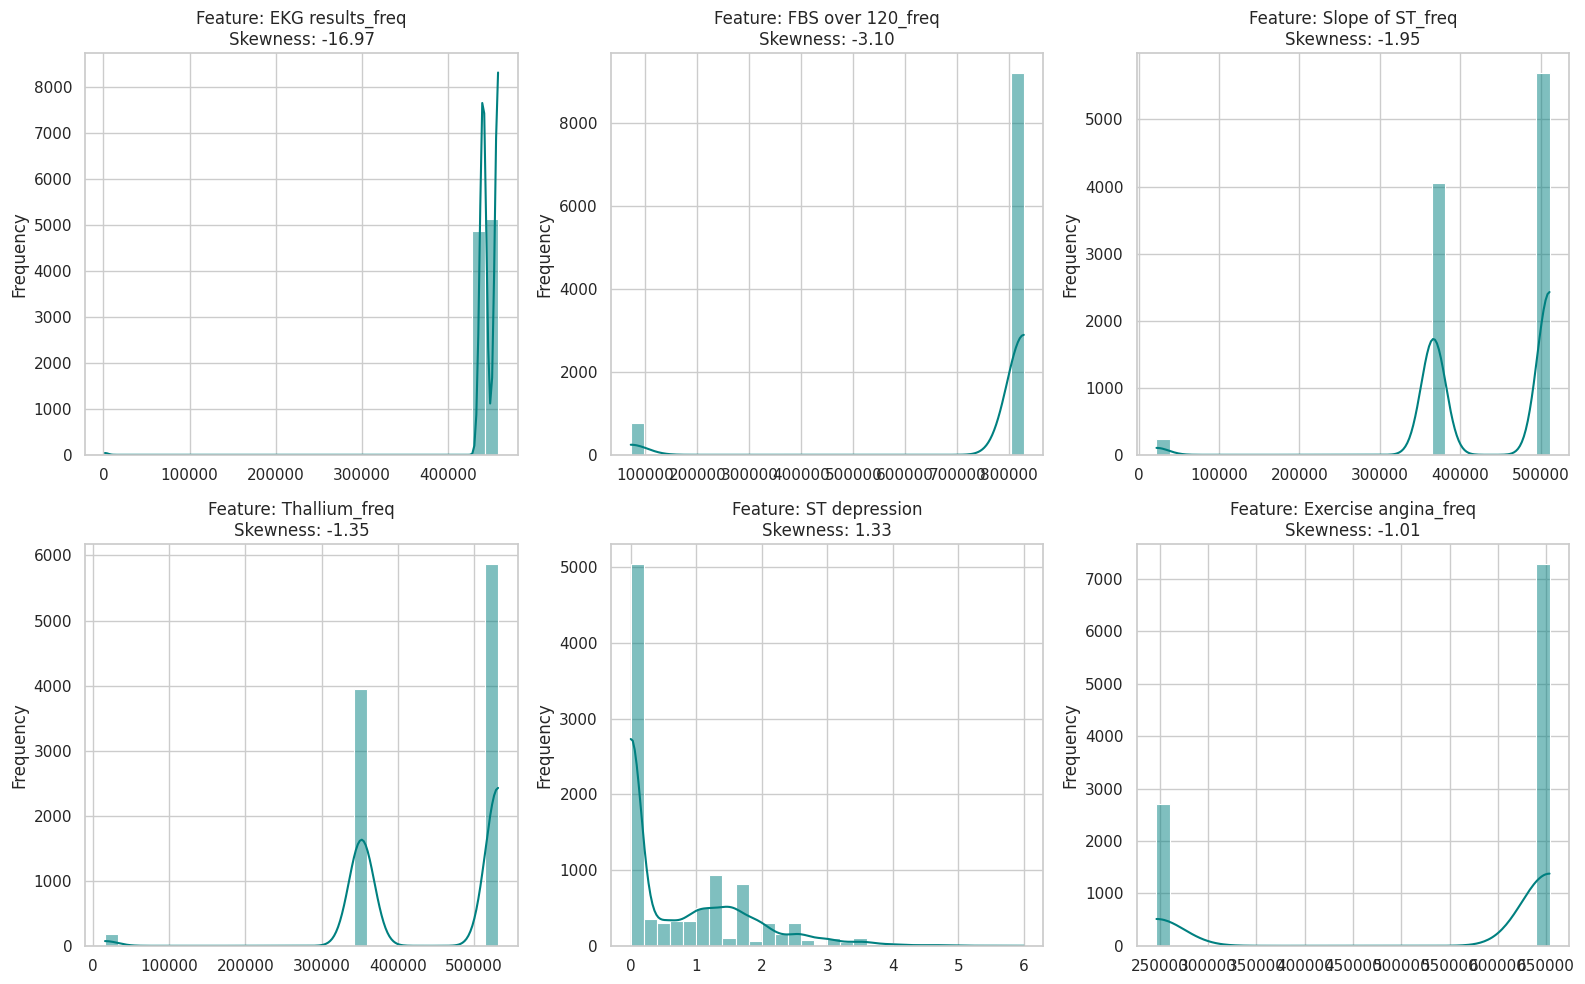

In [17]:
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

skew_series = X[numeric_cols].skew().abs().sort_values(ascending=False)
top_skewed_features = skew_series.head(6).index.tolist()

print("Top 6 Most Skewed Features (Absolute Values):")
print(X[top_skewed_features].skew())

plt.figure(figsize=(16, 10))
for i, col in enumerate(top_skewed_features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(X[col].sample(min(10000, len(X))), kde=True, color='teal', bins=30)
    plt.title(f"Feature: {col}\nSkewness: {X[col].skew():.2f}")
    plt.xlabel("")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Cross-Validation & Training

In [18]:
%%time

# =========================
# Fixed params (Best from HPO)
# =========================
N_FOLDS = 3
RANDOM_STATE = 42
PRIMARY_CONFIG = "numeric_continuous"

params = {
    "device": DEVICE,              # "cuda" or "cpu"
    'random_state': 42,
    'verbosity': 2,
    'n_epochs': 40,
    'batch_size': 256,
    'n_ens': 2,
    'use_early_stopping': True,
    'early_stopping_additive_patience': 20,
    'early_stopping_multiplicative_patience': 1,
    'act': "mish",
    'embedding_size': 8,
    'first_layer_lr_factor': 0.5962121993798933,
    'hidden_sizes': "rectangular",
    'hidden_width': 384,
    'lr': 0.04,
    'ls_eps': 0.011498317194338772,
    'ls_eps_sched': "coslog4",
    'max_one_hot_cat_size': 18,
    'n_hidden_layers': 4,
    'p_drop': 0.07301419697186451,
    'p_drop_sched': "flat_cos",
    'plr_hidden_1': 16,
    'plr_hidden_2': 8,
    'plr_lr_factor': 0.1151437622270563,
    'plr_sigma': 2.3316811282666916,
    'scale_lr_factor': 2.244801835541429,
    'sq_mom': 1.0 - 0.011834054955582318,
    'wd': 0.02369230879235962,
}

print("Using fixed params (submission-style):")
display(pd.Series(params))


Using fixed params (submission-style):


,0
device,cuda
random_state,42
verbosity,2
n_epochs,40
batch_size,256
n_ens,2
use_early_stopping,True
early_stopping_additive_patience,20
early_stopping_multiplicative_patience,1
act,mish


CPU times: user 5.1 ms, sys: 1.01 ms, total: 6.1 ms
Wall time: 15.1 ms


In [20]:
# ---- Evaluate encoding configs ----
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import roc_auc_score

def run_cv_eval(X, X_test, y, params, n_folds, random_state, device, sub_frac=0.3):
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    oof_preds = np.zeros(len(X), dtype=np.float32)
    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]

        if sub_frac is not None and sub_frac < 1.0:
            sss = StratifiedShuffleSplit(
                n_splits=1,
                train_size=int(len(X_tr) * sub_frac),
                random_state=random_state + fold
            )
            sub_idx, _ = next(sss.split(X_tr, y_tr))
            X_tr = X_tr.iloc[sub_idx]
            y_tr = y_tr.iloc[sub_idx]

        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

        model = RealMLP_TD_Classifier(**params)
        model.fit(X_tr, y_tr.values, X_val, y_val.values)

        val_probs = model.predict_proba(X_val)[:, 1]
        oof_preds[val_idx] = val_probs
        fold_scores.append(roc_auc_score(y_val, val_probs))

        if device == "cuda":
            torch.cuda.empty_cache()

    mean_auc = float(np.mean(fold_scores))
    std_auc = float(np.std(fold_scores))
    oof_auc = float(roc_auc_score(y, oof_preds))
    return {"mean_auc": mean_auc, "std_auc": std_auc, "oof_auc": oof_auc}

results = []
for name, feat in features.items():
    print(f"\n=== CV Eval: {name} ===")
    X = feat["X"]
    X_test = feat["X_test"]
    y = feat["y"]

    res = run_cv_eval(X, X_test, y, params, N_FOLDS, RANDOM_STATE, DEVICE, sub_frac=0.3)
    results.append({
        "config": name,
        "mean_auc": res["mean_auc"],
        "std_auc": res["std_auc"],
        "oof_auc": res["oof_auc"],
    })

results_df = pd.DataFrame(results).sort_values(by="oof_auc", ascending=False).reset_index(drop=True)
baseline_auc = float(results_df.loc[results_df["config"] == "raw_numeric", "oof_auc"].iloc[0])
results_df["delta_vs_raw"] = results_df["oof_auc"] - baseline_auc

best_config = results_df.iloc[0]["config"]
print("\nBest config:", best_config)
display(results_df)

PRIMARY_CONFIG = best_config
print(f"PRIMARY_CONFIG set to: {PRIMARY_CONFIG}")



=== CV Eval: raw_numeric ===
Columns classified as continuous: ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression', 'Sex_freq', 'Chest pain type_freq', 'FBS over 120_freq', 'EKG results_freq', 'Exercise angina_freq', 'Slope of ST_freq', 'Number of vessels fluro_freq', 'Thallium_freq']
Columns classified as categorical: ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 1/40: val class_error = 0.114619
Epoch 2/40: val class_error = 0.113124
Epoch 3/40: val class_error = 0.112567
Epoch 4/40: val class_error = 0.113557
Epoch 5/40: val class_error = 0.113162
Epoch 6/40: val class_error = 0.112995
Epoch 7/40: val class_error = 0.112214
Epoch 8/40: val class_error = 0.112224
Epoch 9/40: val class_error = 0.112333
Epoch 10/40: val class_error = 0.113124
Epoch 11/40: val class_error = 0.113190
Epoch 12/40: val class_error = 0.113162
Epoch 13/40: val class_error = 0.114819
Epoch 14/40: val class_error = 0.113329
Epoch 15/40: val class_error = 0.112881
Epoch 16/40: val class_error = 0.112276
Epoch 17/40: val class_error = 0.112262
Epoch 18/40: val class_error = 0.112319
Epoch 19/40: val class_error = 0.112390
Epoch 20/40: val class_error = 0.112629
Epoch 21/40: val class_error = 0.113548
Epoch 22/40: val class_error = 0.112838
Epoch 23/40: val class_error = 0.114290
Epoch 24/40: val class_error = 0.112976
Epoch 25/40: val class_error = 0.113919
Epoch 26/

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Columns classified as continuous: ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression', 'Sex_freq', 'Chest pain type_freq', 'FBS over 120_freq', 'EKG results_freq', 'Exercise angina_freq', 'Slope of ST_freq', 'Number of vessels fluro_freq', 'Thallium_freq']
Columns classified as categorical: ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']


...

Epoch 1/40: val class_error = 0.113819
Epoch 2/40: val class_error = 0.113243
Epoch 3/40: val class_error = 0.113057
Epoch 4/40: val class_error = 0.114462
Epoch 5/40: val class_error = 0.113957
Epoch 6/40: val class_error = 0.113767
Epoch 7/40: val class_error = 0.113071
Epoch 8/40: val class_error = 0.112657
Epoch 9/40: val class_error = 0.113467
Epoch 10/40: val class_error = 0.113110
Epoch 11/40: val class_error = 0.114033
Epoch 12/40: val class_error = 0.116733
Epoch 13/40: val class_error = 0.113433
Epoch 14/40: val class_error = 0.115971
Epoch 15/40: val class_error = 0.113352
Epoch 16/40: val class_error = 0.114771
Epoch 17/40: val class_error = 0.113957
Epoch 18/40: val class_error = 0.114119
Epoch 19/40: val class_error = 0.114214
Epoch 20/40: val class_error = 0.114319
Epoch 21/40: val class_error = 0.114619
Epoch 22/40: val class_error = 0.114110
Epoch 23/40: val class_error = 0.114733
Epoch 24/40: val class_error = 0.114005
Epoch 25/40: val class_error = 0.114529
Epoch 26/

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Best config: periodic_only


,config,mean_auc,std_auc,oof_auc,delta_vs_raw
0,periodic_only,0.954583,0.000182,0.954561,0.000371
1,raw_numeric,0.954220,0.000257,0.954190,0.000000
2,numeric_plus_bins,0.954117,0.000286,0.954101,-0.000089
3,ple_only,0.940915,0.000105,0.940830,-0.013360


PRIMARY_CONFIG set to: periodic_only


In [21]:
from IPython.display import Markdown, display

best_row = results_df.iloc[0]
baseline_row = results_df[results_df["config"] == "raw_numeric"].iloc[0]
periodic_row = results_df[results_df["config"] == "periodic_only"].iloc[0]
ple_row = results_df[results_df["config"] == "ple_only"].iloc[0]
bins_row = results_df[results_df["config"] == "numeric_plus_bins"].iloc[0]

summary_md = f"""
### Encoding Results Summary
- Baseline (raw_numeric) OOF AUC: **{baseline_row['oof_auc']:.5f}**
- Best config: **{best_row['config']}** (OOF AUC **{best_row['oof_auc']:.5f}**, Δ vs baseline **{best_row['delta_vs_raw']:+.5f}**)
- Periodic only Δ vs baseline: **{periodic_row['delta_vs_raw']:+.5f}**
- PLE only Δ vs baseline: **{ple_row['delta_vs_raw']:+.5f}**
- Numeric + bins Δ vs baseline: **{bins_row['delta_vs_raw']:+.5f}**
"""
display(Markdown(summary_md))



### Encoding Results Summary
- Baseline (raw_numeric) OOF AUC: **0.95419**
- Best config: **periodic_only** (OOF AUC **0.95456**, Δ vs baseline **+0.00037**)
- Periodic only Δ vs baseline: **+0.00037**
- PLE only Δ vs baseline: **-0.01336**
- Numeric + bins Δ vs baseline: **-0.00009**


In [22]:
import time
from datetime import datetime
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import roc_auc_score

feat = features[PRIMARY_CONFIG]
X = feat["X"].copy()
X_test = feat["X_test"].copy()
y = feat["y"].copy()

# OOF prediction (dtypes already set in build_features)

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

oof_preds = np.zeros(len(X), dtype=np.float32)
test_preds = np.zeros(len(X_test), dtype=np.float32)
fold_scores = []

t_total_start = time.time()

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    t_fold_start = time.time()

    # ── フォールド開始ログ ──────────────────────────────
    print(f"\n{'='*55}")
    print(f"  Fold {fold}/{N_FOLDS}  |  started at {datetime.now().strftime('%H:%M:%S')}")
    print(f"{'='*55}")

    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]

    SUB_FRAC = 0.3
    sss = StratifiedShuffleSplit(
        n_splits=1,
        train_size=int(len(X_tr) * SUB_FRAC),
        random_state=RANDOM_STATE + fold
    )
    sub_idx, _ = next(sss.split(X_tr, y_tr))
    X_tr = X_tr.iloc[sub_idx]
    y_tr = y_tr.iloc[sub_idx]

    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    print(f"  [data]  train={len(X_tr):,}  val={len(X_val):,}  "
          f"pos_rate(tr)={y_tr.mean():.3f}  pos_rate(val)={y_val.mean():.3f}")

    # ── モデル学習 ──────────────────────────────────────
    print(f"  [fit]   starting RealMLP_TD training ...")
    t_fit = time.time()
    model = RealMLP_TD_Classifier(**params)
    model.fit(X_tr, y_tr.values, X_val, y_val.values)
    print(f"  [fit]   done in {time.time()-t_fit:.1f}s")

    # ── 予測 ────────────────────────────────────────────
    print(f"  [pred]  predicting val & test ...")
    val_probs  = model.predict_proba(X_val)[:, 1]
    test_probs = model.predict_proba(X_test)[:, 1]

    oof_preds[val_idx] = val_probs
    test_preds += test_probs / N_FOLDS

    # ── フォールドスコア ─────────────────────────────────
    score = roc_auc_score(y_val, val_probs)
    fold_scores.append(score)
    elapsed = time.time() - t_fold_start
    total_elapsed = time.time() - t_total_start

    eta = (total_elapsed / fold) * (N_FOLDS - fold)  # 残り時間推定

    print(f"\n  Fold {fold} AUC : {score:.5f}")
    print(f"  Scores so far : {[round(s,5) for s in fold_scores]}")
    print(f"  Running mean  : {np.mean(fold_scores):.5f}  ±  {np.std(fold_scores):.5f}")
    print(f"  Fold time     : {elapsed:.1f}s  |  Total: {total_elapsed:.1f}s  |  ETA: {eta:.1f}s")

    if DEVICE == "cuda":
        torch.cuda.empty_cache()
        print("  [cuda]  cache cleared")

# ── 最終サマリー ──────────────────────────────────────
total_time = time.time() - t_total_start
mean_auc = float(np.mean(fold_scores))
std_auc  = float(np.std(fold_scores))
oof_auc  = float(roc_auc_score(y, oof_preds))

print(f"\n{'#'*55}")
print(f"  CV SUMMARY")
print(f"{'#'*55}")
print(f"  Fold scores : {[round(s,6) for s in fold_scores]}")
print(f"  Mean AUC    : {mean_auc:.6f}")
print(f"  Std AUC     : {std_auc:.6f}")
print(f"  OOF AUC     : {oof_auc:.6f}")
print(f"  Total time  : {total_time:.1f}s  ({total_time/60:.1f}min)")
print(f"{'#'*55}")


  Fold 1/3  |  started at 08:15:53
  [data]  train=126,000  val=210,000  pos_rate(tr)=0.448  pos_rate(val)=0.448
  [fit]   starting RealMLP_TD training ...
Columns classified as continuous: ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression', 'Sex_freq', 'Chest pain type_freq', 'FBS over 120_freq', 'EKG results_freq', 'Exercise angina_freq', 'Slope of ST_freq', 'Number of vessels fluro_freq', 'Thallium_freq', 'Age_sin', 'Age_cos', 'BP_sin', 'BP_cos', 'Cholesterol_sin', 'Cholesterol_cos', 'Max HR_sin', 'Max HR_cos', 'ST depression_sin', 'ST depression_cos']
Columns classified as categorical: ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 1/40: val class_error = 0.113643
Epoch 2/40: val class_error = 0.113076
Epoch 3/40: val class_error = 0.112152
Epoch 4/40: val class_error = 0.113457
Epoch 5/40: val class_error = 0.114048
Epoch 6/40: val class_error = 0.112957
Epoch 7/40: val class_error = 0.112029
Epoch 8/40: val class_error = 0.111929
Epoch 9/40: val class_error = 0.112238
Epoch 10/40: val class_error = 0.112976
Epoch 11/40: val class_error = 0.112229
Epoch 12/40: val class_error = 0.113243
Epoch 13/40: val class_error = 0.115538
Epoch 14/40: val class_error = 0.112467
Epoch 15/40: val class_error = 0.112748
Epoch 16/40: val class_error = 0.112438
Epoch 17/40: val class_error = 0.112924
Epoch 18/40: val class_error = 0.113119
Epoch 19/40: val class_error = 0.113252
Epoch 20/40: val class_error = 0.113657
Epoch 21/40: val class_error = 0.113900
Epoch 22/40: val class_error = 0.114210
Epoch 23/40: val class_error = 0.114605
Epoch 24/40: val class_error = 0.113329
Epoch 25/40: val class_error = 0.112976
Epoch 26/

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


  [fit]   done in 137.1s
  [pred]  predicting val & test ...


...

Epoch 1/40: val class_error = 0.114695
Epoch 2/40: val class_error = 0.112857
Epoch 3/40: val class_error = 0.112719
Epoch 4/40: val class_error = 0.113600
Epoch 5/40: val class_error = 0.113629
Epoch 6/40: val class_error = 0.113252
Epoch 7/40: val class_error = 0.112914
Epoch 8/40: val class_error = 0.112452
Epoch 9/40: val class_error = 0.112590
Epoch 10/40: val class_error = 0.112486
Epoch 11/40: val class_error = 0.113338
Epoch 12/40: val class_error = 0.117438
Epoch 13/40: val class_error = 0.113486
Epoch 14/40: val class_error = 0.114005
Epoch 15/40: val class_error = 0.112919
Epoch 16/40: val class_error = 0.114224
Epoch 17/40: val class_error = 0.113057
Epoch 18/40: val class_error = 0.113490
Epoch 19/40: val class_error = 0.113619
Epoch 20/40: val class_error = 0.113805
Epoch 21/40: val class_error = 0.114090
Epoch 22/40: val class_error = 0.113933
Epoch 23/40: val class_error = 0.113848
Epoch 24/40: val class_error = 0.113143
Epoch 25/40: val class_error = 0.113319
Epoch 26/

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


  [fit]   done in 136.4s
  [pred]  predicting val & test ...


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



  Fold 3 AUC : 0.95481
  Scores so far : [np.float64(0.95457), np.float64(0.95436), np.float64(0.95481)]
  Running mean  : 0.95458  ±  0.00018
  Fold time     : 138.4s  |  Total: 416.6s  |  ETA: 0.0s
  [cuda]  cache cleared

#######################################################
  CV SUMMARY
#######################################################
  Fold scores : [np.float64(0.954575), np.float64(0.954364), np.float64(0.95481)]
  Mean AUC    : 0.954583
  Std AUC     : 0.000182
  OOF AUC     : 0.954561
  Total time  : 416.6s  (6.9min)
#######################################################


### Model Evaluation

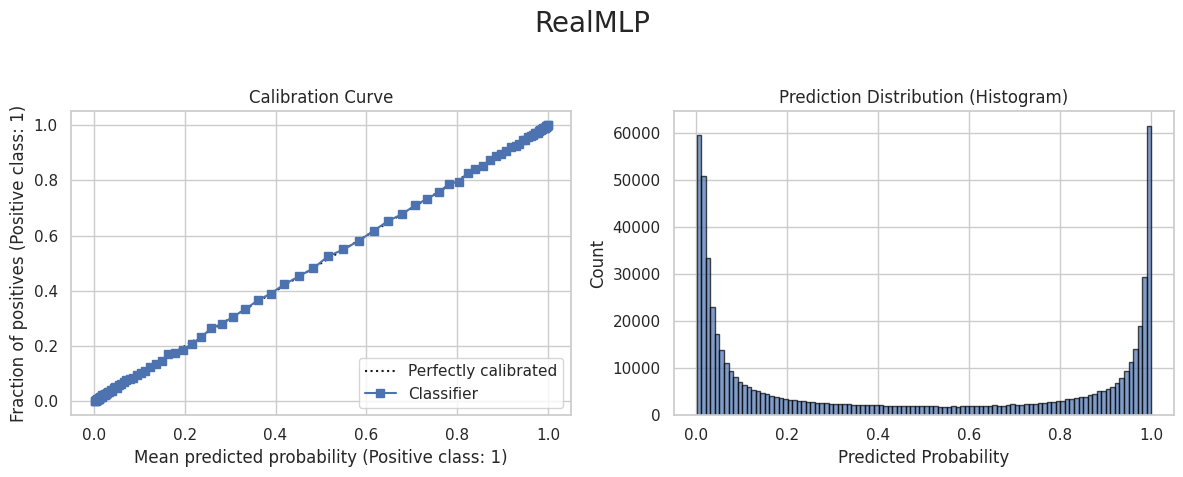

In [23]:
from sklearn.calibration import CalibrationDisplay

plt.figure(figsize=(12, 5))
plt.suptitle('RealMLP', fontsize=20)

ax1 = plt.subplot(1, 2, 1)
CalibrationDisplay.from_predictions(y, oof_preds, n_bins=100, strategy='quantile', ax=ax1)
ax1.set_title('Calibration Curve')

ax2 = plt.subplot(1, 2, 2)
ax2.hist(oof_preds, bins=100, edgecolor='black', alpha=0.7)
ax2.set_title('Prediction Distribution (Histogram)')
ax2.set_xlabel('Predicted Probability')
ax2.set_ylabel('Count')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

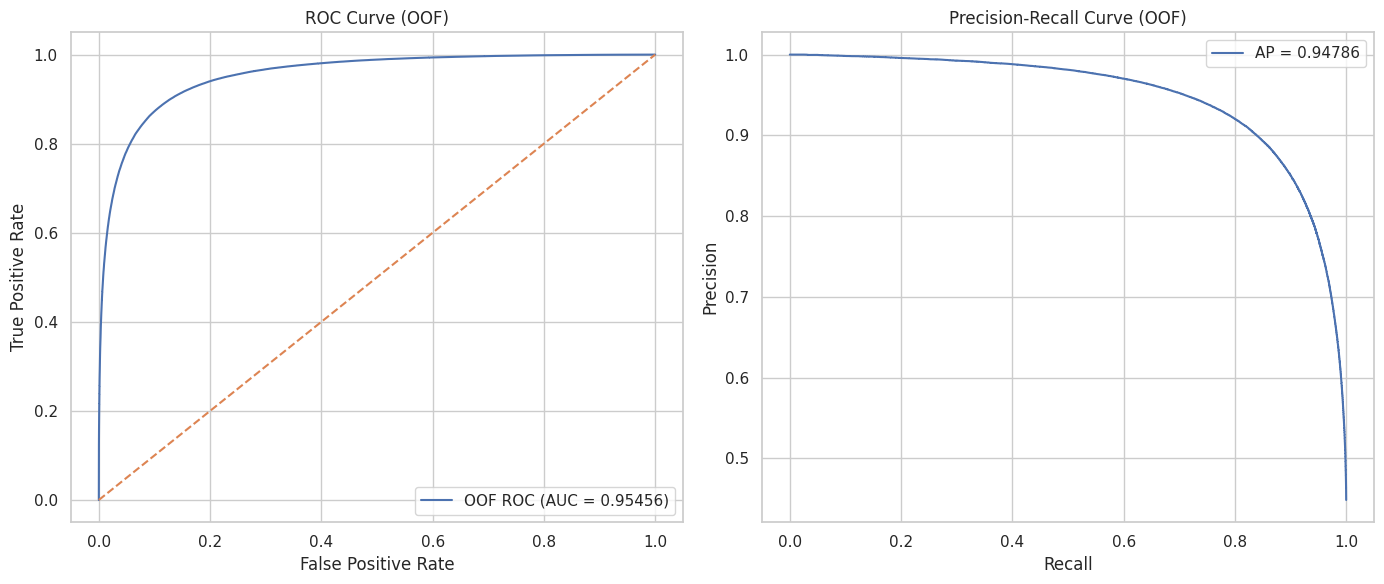

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score
)

# Create figure with 1 row, 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ---- ROC Curve ----
fpr, tpr, _ = roc_curve(y, oof_preds)
roc_auc = auc(fpr, tpr)

ax1.plot(fpr, tpr, label=f'OOF ROC (AUC = {roc_auc:.5f})')
ax1.plot([0, 1], [0, 1], linestyle='--')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve (OOF)')
ax1.legend()
ax1.grid(True)

# ---- Precision-Recall Curve ----
precision, recall, _ = precision_recall_curve(y, oof_preds)
ap = average_precision_score(y, oof_preds)

ax2.plot(recall, precision, label=f'AP = {ap:.5f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve (OOF)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


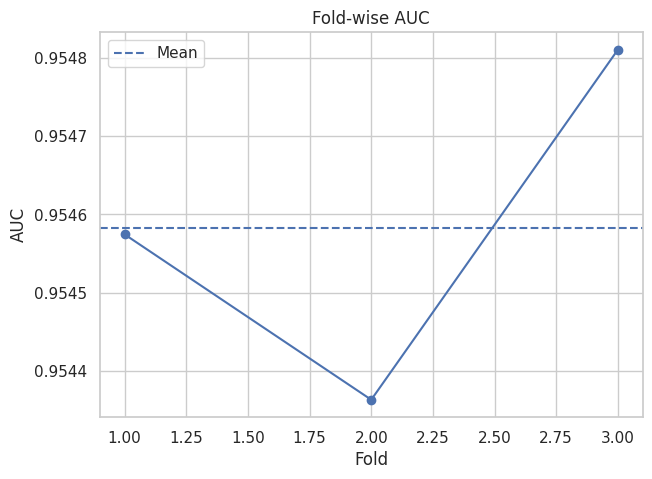

In [25]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, N_FOLDS+1), fold_scores, marker='o')
plt.axhline(np.mean(fold_scores), linestyle='--', label='Mean')

plt.xlabel('Fold')
plt.ylabel('AUC')
plt.title('Fold-wise AUC')
plt.legend()
plt.grid(True)
plt.show()


### Evaluation and Submission

In [26]:
total_oof_score = roc_auc_score(y, oof_preds)

print("\n" + "="*40)
print(f"Overall OOF ROC-AUC (avg OOF): {total_oof_score:.5f}")
print("="*40)

# Save OOF predictions for competition train rows only
comp_len = len(train_comp)
comp_oof = oof_preds[:comp_len]
comp_ids = train_comp['id'].values
pd.DataFrame({'id': comp_ids, 'Heart Disease_prob': comp_oof}).to_csv('oof_preds_train.csv', index=False)
print('OOF predictions saved to oof_preds_train.csv')



Overall OOF ROC-AUC (avg OOF): 0.95456
OOF predictions saved to oof_preds_train.csv


In [27]:
# Fold Scores Table
fold_df = pd.DataFrame({
    "Fold": [f"Fold {i+1}" for i in range(len(fold_scores))],
    "ROC-AUC": fold_scores,
})
fold_df


,Fold,ROC-AUC
0,Fold 1,0.954575
1,Fold 2,0.954364
2,Fold 3,0.954810


In [28]:
submission = pd.DataFrame({'id': test['id'], 'Heart Disease': test_preds})
submission.to_csv('submission.csv', index=False)

print('Submission saved!')
print(f'Shape: {submission.shape}')

if len(submission) != 270000:
    raise ValueError(f"CRITICAL ERROR: Submission row count {len(submission)} != expected 270000")

submission.head()

Submission saved!
Shape: (270000, 2)


,id,Heart Disease
0,630000,0.960489
1,630001,0.007374
2,630002,0.988387
3,630003,0.004456
4,630004,0.202853
